In [1]:
import os 
from dotenv import load_dotenv

load_dotenv()
WANDB_API_KEY = os.getenv("WANDB_API_KEY")


# Load dataset

In [2]:
from torchvision import transforms, datasets
from torch.utils.data import Dataset
from PIL import Image
import torch 
import os 


class FruitDetectionDataset(Dataset):

    def __init__(self, root_dir: str, img_dir, annotations_path: str, transform=None):
        self.root_dir = root_dir
        self.img_dir = img_dir
        self.annotations_path = annotations_path
        self.transform = transform
        self.image_ids = [f for f in os.listdir(os.path.join(self.root_dir, self.img_dir)) if f.endswith('.jpg')]  
        


    def get_annotations(self, image_id: str):

        annotator_path = os.path.join(self.root_dir, self.annotations_path, image_id.replace('.jpg', '.txt'))

        if os.path.exists(annotator_path):
            with open(annotator_path, 'r') as f:
                annotations = f.readlines()
            
            # Parse the annotations
            boxes = []
            labels = []
            for line in annotations:
                parts = line.strip().split()
                label = int(parts[0]) 
                x1, y1, x2, y2 = map(float, parts[1:])
                boxes.append([x1, y1, x2, y2])
                labels.append(label)
            
            return boxes, labels
        

        return [], []  
    
    def __len__(self):
        return len(self.image_ids)
    

    def __getitem__(self, idx): 
        
        image_id = self.image_ids[idx]

        boxes, labels = self.get_annotations(image_id)
        image_path = os.path.join(self.root_dir, self.img_dir, image_id)

        img = Image.open(image_path).convert("RGB")


        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)


        target = {
            "boxes": boxes,
            "labels": labels
        }   

        if self.transform:
            img = self.transform(img)



        return img, target


In [3]:
import torchvision.transforms as transforms


def get_transfrom(is_train : bool = True):

    if is_train: 
        return transforms.Compose([
            transforms.Resize((640, 640)),
            transforms.RandomHorizontalFlip(0.5),
            transforms.PILToTensor(),
            transforms.ConvertImageDtype(torch.float)
        ])
    else:
        return transforms.Compose([
            transforms.Resize((640, 640)),
            transforms.PILToTensor(),
            transforms.ConvertImageDtype(torch.float)
        ])

In [4]:
train_dataset = FruitDetectionDataset( 
    root_dir='data/Dataset',
    img_dir='Train/images',
    annotations_path='Train/labels',
    transform = get_transfrom(is_train=True)
) 

In [5]:
train_dataset[5]

(tensor([[[0.5804, 0.5804, 0.5804,  ..., 0.4627, 0.4627, 0.4667],
          [0.5804, 0.5804, 0.5804,  ..., 0.4627, 0.4627, 0.4667],
          [0.5804, 0.5804, 0.5804,  ..., 0.4627, 0.4627, 0.4667],
          ...,
          [0.8863, 0.8902, 0.8902,  ..., 0.7765, 0.7765, 0.7765],
          [0.8863, 0.8863, 0.8902,  ..., 0.7765, 0.7765, 0.7765],
          [0.8863, 0.8863, 0.8863,  ..., 0.7765, 0.7765, 0.7765]],
 
         [[0.3373, 0.3373, 0.3373,  ..., 0.2275, 0.2275, 0.2314],
          [0.3373, 0.3373, 0.3373,  ..., 0.2275, 0.2275, 0.2314],
          [0.3373, 0.3373, 0.3373,  ..., 0.2275, 0.2275, 0.2314],
          ...,
          [0.6118, 0.6157, 0.6157,  ..., 0.5373, 0.5373, 0.5373],
          [0.6118, 0.6118, 0.6157,  ..., 0.5373, 0.5373, 0.5373],
          [0.6118, 0.6118, 0.6118,  ..., 0.5373, 0.5373, 0.5373]],
 
         [[0.0431, 0.0431, 0.0431,  ..., 0.0235, 0.0235, 0.0275],
          [0.0431, 0.0431, 0.0431,  ..., 0.0235, 0.0235, 0.0275],
          [0.0431, 0.0431, 0.0431,  ...,

In [6]:
def get_unique_classes(dataset):
    """
    Lấy tất cả các class labels duy nhất từ dataset
    """
    all_labels = set()
    
    for i in range(len(dataset)):
        _, target = dataset[i]
        labels = target['labels'].numpy()
        all_labels.update(labels)
    
    return sorted(list(all_labels))

# Sử dụng hàm trên dataset
# unique_classes = get_unique_classes(train_dataset)
# print(f"Các class trong dataset: {unique_classes}")

In [8]:
from torchvision.utils import draw_bounding_boxes
import matplotlib.pyplot as plt


def show_image_with_boxes(idx):

    img, target = train_dataset[idx]
    boxes = target['boxes']
    labels = target['labels']
    label_strings = [str(label.item()) for label in labels]
    # Draw bounding boxes on the image
    img_with_boxes = draw_bounding_boxes(img, boxes, labels=label_strings, colors="red", width=3)

    # Convert to numpy array for plotting
    img_with_boxes = img_with_boxes.permute(1, 2, 0).numpy()

    plt.figure(figsize=(10, 10))
    plt.imshow(img_with_boxes)
    plt.axis('off')
    plt.show()



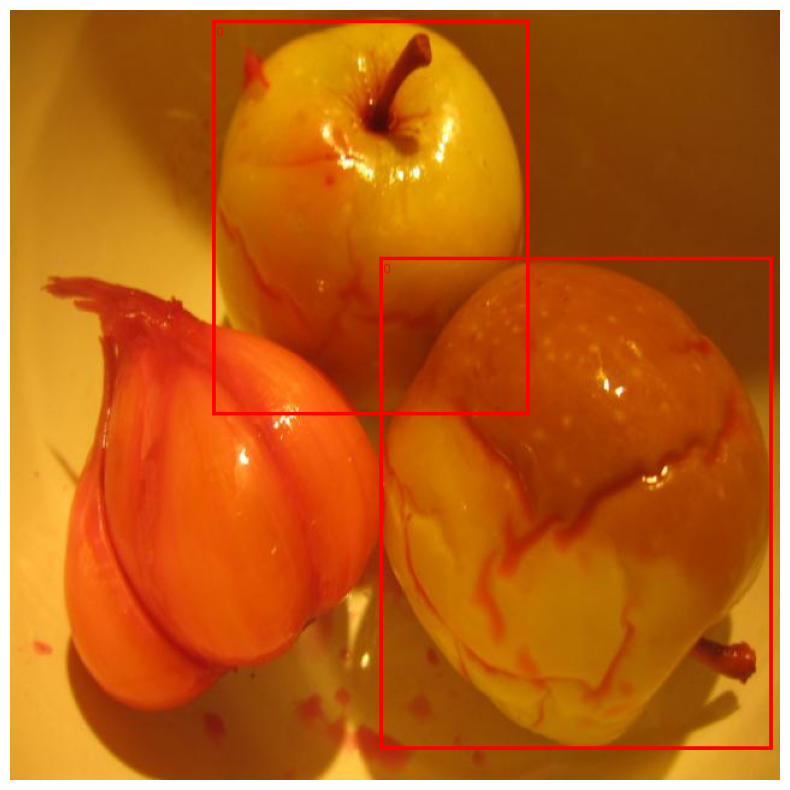

In [9]:
show_image_with_boxes(5)

In [10]:
_, target = train_dataset[5]

print(target['boxes'])

print(target['labels'])


print(f"len of idx 2: {len(target['boxes'])}")
print(f"len of idx 2: {len(target['labels'])}")

tensor([[168.2500,   8.7500, 431.7500, 336.2500],
        [307.0000, 205.5000, 633.0000, 614.5000]])
tensor([0, 0])
len of idx 2: 2
len of idx 2: 2


# Datamodule

In [11]:
import lightning as pl 
from torch.utils.data import DataLoader, random_split


class FruitDatamodule(pl.LightningDataModule):
    def __init__(self, root_dir: str, img_dir: str, annotations_path: str, transforms = None, batch_size: int = 32, train_val_ratio: float = 0.9):
        super().__init__()
        self.root_dir = root_dir
        self.img_dir = img_dir
        self.annotations_path = annotations_path
        self.batch_size = batch_size

        self.transforms = transforms
        self.train_val_ratio = train_val_ratio

    def setup(self, stage=None):
            
        self.train_dataset = FruitDetectionDataset(
            root_dir=self.root_dir,
            img_dir=self.img_dir,
            annotations_path=self.annotations_path,
            transform=self.transforms
        )
        if stage == 'fit' or stage is None:

            train_size, val_size = int(len(self.train_dataset) * self.train_val_ratio), len(self.train_dataset) - int(len(self.train_dataset) * self.train_val_ratio)

            self.train_dataset, self.val_dataset = random_split(
                self.train_dataset,
                [train_size, val_size]
            )


        if stage == 'test' or stage is None:


            test_size = len(self.train_dataset) - int(len(self.train_dataset) * self.train_val_ratio)

            self.test_dataset = random_split(
                self.train_dataset,
                [test_size]
            )[0]
    
    @staticmethod
    def collate_fn(batch):
        return tuple(zip(*batch))

    def train_dataloader(self):
        return DataLoader( self.train_dataset, batch_size=self.batch_size, shuffle=True, num_workers=4, collate_fn=self.collate_fn )


    def val_dataloader(self):
        return DataLoader( self.val_dataset, batch_size=self.batch_size, shuffle=False, num_workers=4, collate_fn=self.collate_fn )

    def test_dataloader(self):
        return DataLoader( self.test_dataset, batch_size=self.batch_size, shuffle=False, num_workers=4 , collate_fn=self.collate_fn )

# Model 

In [ ]:
from ultralytics import YOLO 


def get_model(model_name: str = "yolov8n.pt", num_classes: int = 1):
    model = YOLO(model_name)
    model.model.model[-1].num_classes = num_classes


    
    return model

In [13]:
from torchvision.models.detection import fasterrcnn_mobilenet_v3_large_fpn, fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchmetrics.detection import MeanAveragePrecision, IntersectionOverUnion
import torch.optim as optim 

class FruitDetectionModel(pl.LightningModule):
    def __init__(self, num_classes: int, learning_rate: float = 0.001):
        super().__init__()


        self.model = fasterrcnn_mobilenet_v3_large_fpn(pretrained=True)
        in_features = self.model.roi_heads.box_predictor.cls_score.in_features
        self.model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

        self.train_map = MeanAveragePrecision()
        self.val_map = MeanAveragePrecision()
        self.test_map = MeanAveragePrecision()


        self.train_iou = IntersectionOverUnion()
        self.val_iou = IntersectionOverUnion()
        self.test_iou = IntersectionOverUnion()


        self.learning_rate = learning_rate


    def forward(self, images, targets=None):
        return self.model(images, targets)


    def training_step(self, batch, batch_idx):
        images, targets = batch 

        images = list(image for image in images)
        targets = [{k: v for k, v in t.items()} for t in targets]


        loss_dict = self.model(images, targets)

        losses = sum(loss for loss in loss_dict.values())

        
        self.log('train/loss', losses.detach(), prog_bar=True, on_step=True, on_epoch=True)
        for k, v in loss_dict.items():
            self.log(f"train/{k}", v.detach(), on_step=True, on_epoch=True, prog_bar=True)


        if batch_idx % 50 == 0: 
            self.model.eval()
            with torch.no_grad():
                predictions = self.model(images)
            self.model.train()


            preds = [
                {
                    'boxes': pred['boxes'],
                    'scores': pred['scores'],
                    'labels': pred['labels']
                }
                for pred in predictions
            ]
            

            targets = [
                {
                    'boxes': target['boxes'],
                    'labels': target['labels']
                }
                for target in targets
            ]

            self.train_map.update(preds, targets)
            self.train_iou.update(preds, targets)

        return losses



    def on_train_epoch_end(self):
        map_score = self.train_map.compute()
        iou_score = self.train_iou.compute()

        self.log('train/mAP', map_score['map'], prog_bar=True)
        self.log('train/IoU', iou_score['iou'], prog_bar=True)
        self.log('train/mAP_50', map_score['map_50'], prog_bar=True)


        self.train_map.reset()
        self.train_iou.reset()


    def validation_step(self, batch, batch_idx):
        images, targets = batch 

        images = list(image for image in images)
        targets = [{k: v for k, v in t.items()} for t in targets]

        preds = self.model(images)
        self.val_map.update(preds, targets)
        self.val_iou.update(preds, targets)

        

    def on_validation_epoch_end(self):
        map_score = self.val_map.compute()
        iou_score = self.val_iou.compute()

        self.log('val/mAP', map_score['map'], prog_bar=True)
        self.log('val/IoU', iou_score['iou'], prog_bar=True)
        self.log('val/mAP_50', map_score['map_50'], prog_bar=True)


        self.val_map.reset()
        self.val_iou.reset()


    def test_step(self, batch, batch_idx):
        images, targets = batch 

        images = list(image for image in images)
        targets = [{k: v for k, v in t.items()} for t in targets]

        preds = self.model(images)
        self.test_map.update(preds, targets)
        self.test_iou.update(preds, targets)


    def on_test_epoch_end(self):

        map_score = self.test_map.compute()
        iou_score = self.test_iou.compute()

        self.log('test/mAP', map_score['map'], prog_bar=True)
        self.log('test/IoU', iou_score['iou'], prog_bar=True)
        self.log('test/mAP_50', map_score['map_50'], prog_bar=True)


        self.test_map.reset()
        self.test_iou.reset()



    def configure_optimizers(self):
        optimizer = optim.Adam(self.parameters(), lr=self.learning_rate)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau( optimizer, mode='max', factor=0.5, patience=2)

        return {
            'optimizer': optimizer,
            'lr_scheduler': {
                'scheduler': scheduler,
                'monitor': 'val/mAP',
                'interval': 'epoch',
                'frequency': 1
            }
        }





In [14]:
import wandb 
from lightning.pytorch.loggers import WandbLogger
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping

wandb.login(key=WANDB_API_KEY)




datamodule = FruitDatamodule(
    root_dir='data/Dataset',
    img_dir='Train/images',
    annotations_path='Train/labels',
    transforms=get_transfrom(is_train=True),
    batch_size=8,
    train_val_ratio=0.9
)

model = FruitDetectionModel(
    num_classes=6,
    learning_rate=0.001
)

wandb_logger = WandbLogger(project="fruit-detection", name = "mobilenet_v3_large_fpn with augmented", log_model=True)


trainer = pl.Trainer(
    accelerator='gpu',
    devices=1,
    max_epochs=30,
    logger=wandb_logger,
    callbacks=[
        ModelCheckpoint(monitor='val/mAP', mode='max', save_top_k=1),
        EarlyStopping(monitor='val/mAP', patience=3, mode='max')
    ],
    enable_progress_bar=True,
)



/workspace/thviet/paracrawl/tools/miniconda3/envs/img_env/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/workspace/thviet/paracrawl/tools/miniconda3/envs/img_env/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_MobileNet_V3_Large_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_MobileNet_V3_Large_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/workspace/thviet/paracrawl/tools/miniconda3/envs/img_env/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Li

In [15]:
trainer.fit(model, datamodule)

You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type                  | Params | Mode 
------------------------------------------------------------
0 | model     | FasterRCNN            | 19.0 M | train
1 | train_map | MeanAveragePrecision  | 0      | train
2 | val_map   | MeanAveragePrecision  | 0      | train
3 | test_map  | MeanAveragePrecision  | 0      | train
4 | train_iou | IntersectionOverUnion | 0      | train
5 | val_iou   | IntersectionOverUnion | 0      | train
6 | test_iou  | IntersectionOverUnion | 0      | train
------------------------------------------------------------
18.9 M    Trainable params
58.9 K    Non-trainable params
19.0 M    Total params
75.803    Total estimated model params size (MB)
286       Modules in train mode
0         Modules in eval mode


Epoch 0:   0%|          | 0/859 [00:00<?, ?it/s]                           

/workspace/thviet/paracrawl/tools/miniconda3/envs/img_env/lib/python3.11/site-packages/lightning/pytorch/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 3. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.


Epoch 1:   7%|▋         | 56/859 [00:12<02:53,  4.62it/s, v_num=xy8i, train/loss_step=2.010, train/loss_classifier_step=1.300, train/loss_box_reg_step=0.127, train/loss_objectness_step=0.527, train/loss_rpn_box_reg_step=0.052, val/mAP=5.68e-5, val/IoU=0.0682, val/mAP_50=0.000204, train/loss_epoch=7.640, train/loss_classifier_epoch=1.900, train/loss_box_reg_epoch=1.700, train/loss_objectness_epoch=2.630, train/loss_rpn_box_reg_epoch=1.410, train/mAP=0.0171, train/IoU=0.0561, train/mAP_50=0.045]  


Detected KeyboardInterrupt, attempting graceful shutdown ...


NameError: name 'exit' is not defined

Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x7f1577d73f10>> (for post_run_cell), with arguments args (<ExecutionResult object at 7f15df541090, execution_count=15 error_before_exec=None error_in_exec=name 'exit' is not defined info=<ExecutionInfo object at 7f15df53bc50, raw_cell="trainer.fit(model, datamodule)" store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2B210.245.53.88/workspace/thviet/trungnnv/AIT3002-image-processing/final/object_detection/fruit-detection.ipynb#X20sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe